In [18]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\Himanshu Jain\Downloads\recommendation-system\.venv\Scripts\python.exe -m pip install --upgrade pip' command.


In [1]:
import pandas as pd

ratings = pd.read_csv("../sample_data/inputs/ml-latest-small/ratings.csv")
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [2]:
n_ratings = len(ratings) ## count total length of the dataset
n_users = ratings['userId'].nunique() ## count number of distinct users
n_movies = ratings['movieId'].nunique() ## count number of distinct Movie titles

print(f"Ratings: {n_ratings}")
print(f"Users: {n_users}")
print(f"Movies: {n_movies}")

Ratings: 100836
Users: 610
Movies: 9724


In [3]:
sparsity = 1 - (n_ratings / (n_users * n_movies))
print(f"Sparsity: {sparsity:.2%}")

Sparsity: 98.30%


The sparsity percentage of this dataset is 98.3% meaning that most of the users-movie pair  have no rating  very few movies and that is why collaborative filtering will not work well here as there is not much pattern to learn from this justifies our hybrid model approch.

In [5]:
movie_counts = ratings['movieId'].value_counts()
movie_counts.head(10)

movieId
356     329
318     317
296     307
593     279
2571    278
260     251
480     238
110     237
589     224
527     220
Name: count, dtype: int64

In [ ]:
## Getting the most rated movie by title 

movies = pd.read_csv("../sample_data/inputs/ml-latest-small/movies.csv")
movies.head()
top10 = movie_counts.head(10).reset_index()
top10.columns = ['movieId', 'num_ratings']
top10_named = movies.merge( top10 , how  = "inner", on = "movieId")
top10_named = top10_named.sort_values(by = "num_ratings", ascending= False)
top10_named



,movieId,title,genres,num_ratings
4,356,Forrest Gump (1994),Comedy|Drama|Romance|War,329
3,318,"Shawshank Redemption, The (1994)",Crime|Drama,317
2,296,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,307
8,593,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller,279
9,2571,"Matrix, The (1999)",Action|Sci-Fi|Thriller,278
1,260,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi,251
5,480,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller,238
0,110,Braveheart (1995),Action|Drama|War,237
7,589,Terminator 2: Judgment Day (1991),Action|Sci-Fi,224
6,527,Schindler's List (1993),Drama|War,220


In [12]:
## Getting the avg rating for the top 10 most rated movies

avg_ratings = ratings.groupby('movieId')['rating'].mean()
top10_named['avg_rating'] = top10_named['movieId'].map(avg_ratings)
top10_named



,movieId,title,genres,num_ratings,avg_rating
4,356,Forrest Gump (1994),Comedy|Drama|Romance|War,329,4.164134
3,318,"Shawshank Redemption, The (1994)",Crime|Drama,317,4.429022
2,296,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,307,4.197068
8,593,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller,279,4.161290
9,2571,"Matrix, The (1999)",Action|Sci-Fi|Thriller,278,4.192446
1,260,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi,251,4.231076
5,480,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller,238,3.750000
0,110,Braveheart (1995),Action|Drama|War,237,4.031646
7,589,Terminator 2: Judgment Day (1991),Action|Sci-Fi,224,3.970982
6,527,Schindler's List (1993),Drama|War,220,4.225000


Popularity ≠ quality. Movie 527 (Schindler's List) has fewer total ratings (220) than movie 356 (Forrest Gump, 329) , the most-rated movie overall , yet has a higher average rating (4.23 vs. 4.16). Even more notable: Jurassic Park has more ratings (238) than Schindler's List, but the lowest average (3.75) in the entire top 10.

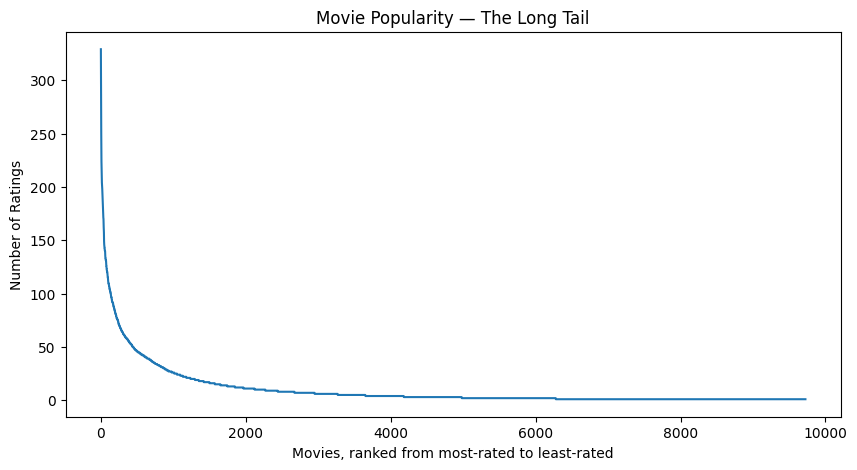

In [20]:
plt.figure(figsize=(10, 5))
plt.plot(range(len(movie_counts)), movie_counts.values)
plt.title("Movie Popularity — The Long Tail")
plt.xlabel("Movies, ranked from most-rated to least-rated")
plt.ylabel("Number of Ratings")
plt.show()

In [14]:
uniform_share = 1 / n_movies
top_movie_share = movie_counts.iloc[0] / n_ratings

print(f"If ratings were spread evenly, each movie would get: {uniform_share:.4%}")
print(f"The most-rated movie actually got:                   {top_movie_share:.4%}")
print(f"That's {top_movie_share / uniform_share:.1f}x the 'fair share'")

top10pct_count = int(n_movies * 0.10)
share = movie_counts.head(top10pct_count).sum() / n_ratings
print(f"\nTop 10% of movies ({top10pct_count} movies) account for {share:.1%} of all ratings")

If ratings were spread evenly, each movie would get: 0.0103%
The most-rated movie actually got:                   0.3263%
That's 31.7x the 'fair share'

Top 10% of movies (972 movies) account for 60.0% of all ratings


There is one striking differnce that is top 10% most popular movies account for 60% of the ratings and the remaning 90% of the movies account for just 40% of the ratings , and that is why personaliztion is important because if we were to recommend movies just based on popularity defined by number of ratings we would never recommened from remaning 90% of movie to the user no matter how suited it is to their taste 

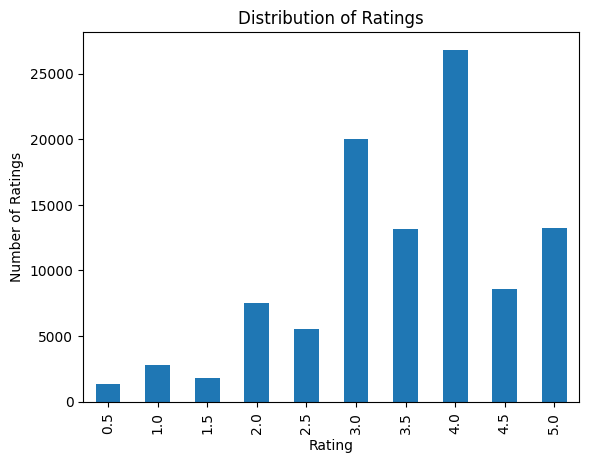

In [19]:
import matplotlib.pyplot as plt

ratings['rating'].value_counts().sort_index().plot(kind='bar')
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")
plt.show()

In [16]:
ratings['rating'].value_counts(normalize=True).sort_index(ascending= False)

rating
5.0    0.131015
4.5    0.084801
4.0    0.265957
3.5    0.130271
3.0    0.198808
2.5    0.055040
2.0    0.074884
1.5    0.017762
1.0    0.027877
0.5    0.013586
Name: proportion, dtype: float64

About 48% of all ratings are 4 stars or higher. This is helpful as it will help us define our hit metric. AS we will define our hit as (rating>=4)


In [17]:
pd.to_datetime(ratings['timestamp'], unit='s').describe()

count                           100836
mean     2008-03-19 17:01:27.368469248
min                1996-03-29 18:36:55
25%                2002-04-18 09:57:46
50%                2007-08-02 20:31:02
75%         2015-07-04 07:15:44.500000
max                2018-09-24 14:27:30
Name: timestamp, dtype: object

Ratings span 22 years (1996–2018) with uneven density across time so a per-user time-based split is the right approach rather than a single global date cutoff which could leave many users with no held-out data.